In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

In [4]:
# 2. Display the first five rows of the dataset[cite: 1]
print("--- First 5 Rows ---")
display(df.head())

--- First 5 Rows ---


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
# 3. Display the shape and summary information of the dataset[cite: 1]
print("\n--- Dataset Shape ---")
print(df.shape)

print("\n--- Summary Info ---")
df.info()


--- Dataset Shape ---
(442, 11)

--- Summary Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [7]:
# 4. Select: Input feature (X): bmi , Target variable (y): target[cite: 1]
X = df[['bmi']]  # Double brackets keep X as a DataFrame (2D array)[cite: 1]
y = df['target']

In [9]:
# 5. Split dataset into training and testing sets (80:20 ratio, random_state=42)[cite: 1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)#[cite: 1]

In [12]:
# 6. Train a Linear Regression model & display slope and intercept[cite: 1]
model = LinearRegression()#[cite: 1]
model.fit(X_train, y_train)

print(f"\nSlope (Coefficient): {model.coef_[0]:.4f}")#[cite: 1]
print(f"Intercept: {model.intercept_:.4f}")#[cite: 1]


Slope (Coefficient): 998.5777
Intercept: 152.0034


In [13]:
# 7. Predict the target values for the test data[cite: 1]
y_pred = model.predict(X_test)#[cite: 1]

In [15]:
# 8. Evaluate the model using MSE and R² Score[cite: 1]
mse = mean_squared_error(y_test, y_pred)#[cite: 1]
r2 = r2_score(y_test, y_pred)#[cite: 1]

print(f"Mean Squared Error (MSE): {mse:.4f}")#[cite: 1]
print(f"R² Score: {r2:.4f}")#[cite: 1]

Mean Squared Error (MSE): 4061.8259
R² Score: 0.2334


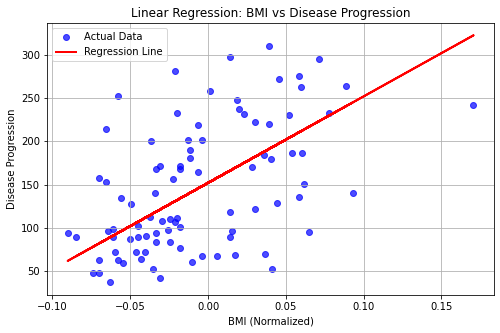

In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', alpha=0.7, label='Actual Data')

# Fixed line: converted X_test to a numpy array using .values
plt.plot(X_test.values, y_pred.flatten(), color='red', linewidth=2, label='Regression Line') 

plt.xlabel('BMI (Normalized)')
plt.ylabel('Disease Progression')
plt.title('Linear Regression: BMI vs Disease Progression')
plt.legend()
plt.grid(True)
plt.show()


In [22]:
# 10. Predict disease progression for a patient with BMI = 0.05[cite: 1]
sample_bmi = pd.DataFrame({'bmi': [0.05]})
sample_pred = model.predict(sample_bmi)
print(f"\nPredicted disease progression for BMI = 0.05: {sample_pred[0]:.4f}")#[cite: 1]



Predicted disease progression for BMI = 0.05: 201.9322


In [26]:
# Select multiple input features[cite: 1]
X_multi = df[['age', 'bmi', 'bp', 's1']]#[cite: 1]
y_multi = df['target']#[cite: 1]

# Split the dataset[cite: 1]
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)#[cite: 1]

# Train the multi-feature linear regression model
multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

# Display results
print("--- Multi-Feature Model Results ---")
for feature, coef in zip(X_multi.columns, multi_model.coef_):
    print(f"Coefficient ({feature}): {coef:.4f}")
print(f"Intercept: {multi_model.intercept_:.4f}")#[cite: 1]

# Evaluate
y_pred_m = multi_model.predict(X_test_m)
print(f"\nMean Squared Error (MSE): {mean_squared_error(y_test_m, y_pred_m):.4f}")#[cite: 1]
print(f"R² Score: {r2_score(y_test_m, y_pred_m):.4f}")#[cite: 1]


--- Multi-Feature Model Results ---
Coefficient (age): 48.3174
Coefficient (bmi): 836.0403
Coefficient (bp): 380.1696
Coefficient (s1): 0.3807
Intercept: 151.7676

Mean Squared Error (MSE): 3756.4507
R² Score: 0.2910
